# Exploratory Data Analysis: Bivariate Analysis

The objective of this section is to explore and understand the relationships between pairs of variables in the student performance dataset. Bivariate analysis is conducted to identify correlations, trends, and differences between numerical and/or categorical features, revealing how one variable may influence or relate to another.

The analysis focuses on key combinations of variables, such as student grades, motivation, study habits, and demographics, to uncover patterns in performance and behavior. Visualizations including scatterplots, line charts, and boxplots are used to illustrate these relationships and highlight differences across groups or trends over time.
The datasets used in this analysis are:

- `ensia_cleaned_1Y_grouped_imputed.csv`
- `ensia_cleaned_2Y_grouped_imputed.csv`
- `ensia_cleaned_3Y_grouped_imputed.csv`


In [18]:
# Importing requireed libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
#reading data from csv files 
data_1y = pd.read_csv('../data/outputs/grouped_imputed/ensia_cleaned_1Y_grouped_imputed.csv')
data_2y = pd.read_csv('../data/outputs/grouped_imputed/ensia_cleaned_2Y_grouped_imputed.csv')
data_3y = pd.read_csv('../data/outputs/grouped_imputed/ensia_cleaned_3Y_grouped_imputed.csv')
print("Data Loaded Successfully")
print("Data 1Y shape:", data_1y.shape)
data_1y.head()
print("Data 2Y shape:", data_2y.shape)
data_2y.head() 
print("Data 3Y shape:", data_3y.shape)
data_3y.head()

Data Loaded Successfully
Data 1Y shape: (210, 45)
Data 2Y shape: (101, 45)
Data 3Y shape: (12, 45)


,record_id,what is your gender,in which year of your studies are you currently enrolled,what was your bac specialty,how many hours per week do you spend studying personnal efforts,where do you prefer to study,you prefer to study,what learning methods do help you understand better,what types of resources do you use most,do you use a planer or a schedule in your revisions,...,3y average s2,3y average,3Y_math_avg,3Y_math_n,3Y_programming_avg,3Y_programming_n,3Y_other_avg,3Y_other_n,3Y_all_modules_avg,3Y_all_modules_n
0,45,Female,Fourth year,Technical maths,10-17,In your room (dorms),Alone,Lectures;Learning by practicing;Mind mapping a...,Books;Online tutorials;Online documents;YouTub...,Yes,...,13.0,12.0,2.750,4,2.714286,7,5.0,1,2.916667,12
1,78,Male,Fourth year,Technical maths,10-17,In your room (dorms),Alone,Mind mapping and visualization,Books;YouTube videos,Yes,...,11.0,10.0,3.125,0,3.071429,0,4.0,0,3.208333,0
2,80,Male,Fourth year,Technical maths,10-17,At home,In peer,Lectures;Learning by practicing;Project-based ...,Books;Online documents,No,...,13.0,13.0,3.500,4,3.428571,7,4.0,1,3.500000,12
3,84,Female,Fourth year,Mathematics,10-17,In your room (dorms),Alone,Learning by practicing;Project-based learning;...,Online tutorials;YouTube videos,Yes,...,10.0,10.0,3.125,0,3.071429,0,4.0,0,3.208333,0
4,86,Female,Fourth year,Mathematics,10-17,In your room (dorms),In peer,Learning by practicing;Mind mapping and visual...,Online documents;YouTube videos,Yes,...,11.0,10.0,3.125,0,3.071429,0,4.0,0,3.208333,0


# 1) Numerical-Numerical Data relationships 

### a.Yearly Average vs Motivation

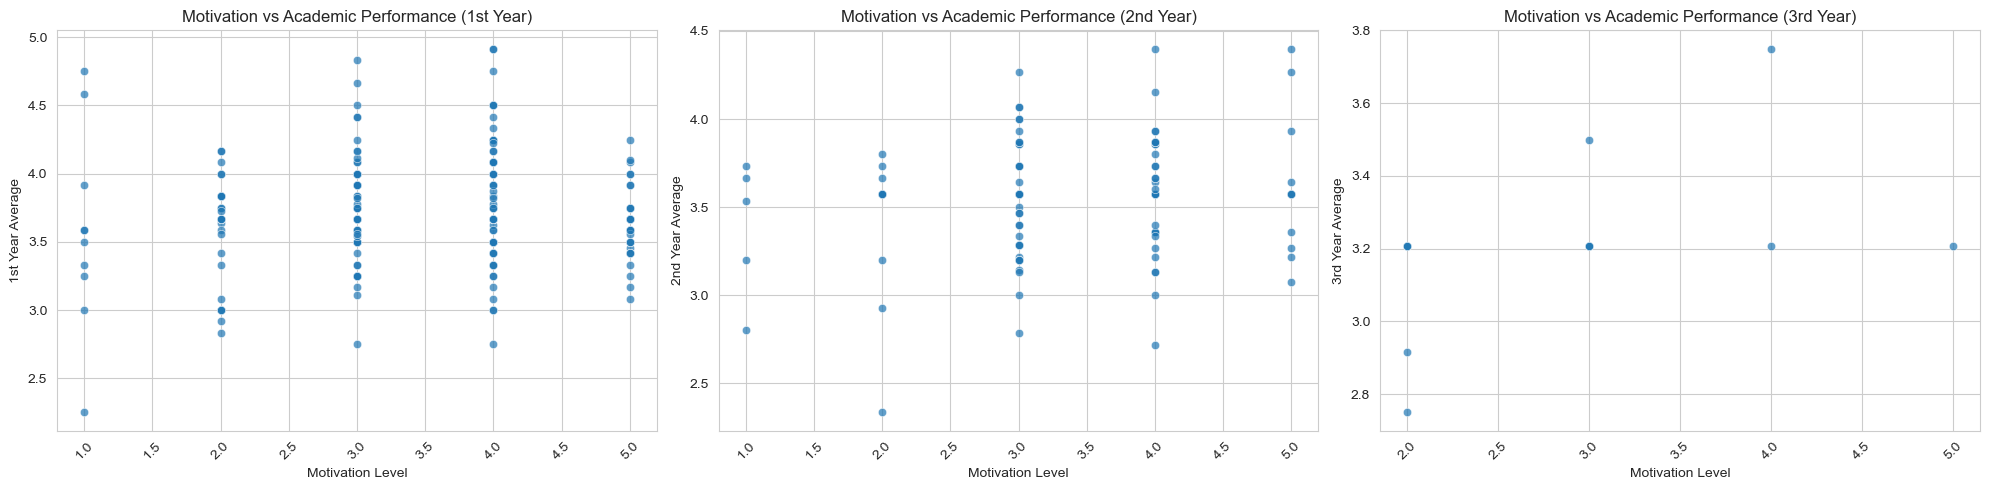

In [9]:


sns.set_style('whitegrid')

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(20,5))

# Plot 1: 1 year average vs motivation scatter plot
sns.scatterplot(
    x=data_1y['your level of motivation for joining ensia'],
    y=data_1y['1Y_all_modules_avg'],
    alpha=0.7,
    ax=axes[0]
)
axes[0].set_title('Motivation vs Academic Performance (1st Year)')
axes[0].set_ylabel('1st Year Average')
axes[0].set_xlabel('Motivation Level')
axes[0].tick_params(axis='x', rotation=45)
plt.tight_layout()
# Plot 2: 2 year average vs motivation scatter plot
sns.scatterplot(
    x=data_2y['your level of motivation for joining ensia'],
    y=data_2y['2Y_all_modules_avg'],
    alpha=0.7,
    ax=axes[1]
)
axes[1].set_title('Motivation vs Academic Performance (2nd Year)')
axes[1].set_ylabel('2nd Year Average')
axes[1].set_xlabel('Motivation Level')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
# Plot 3: 3 year average vs motivation scatter plot
sns.scatterplot(
    x=data_3y['your level of motivation for joining ensia'],
    y=data_3y['3Y_all_modules_avg'],
    alpha=0.7,
    ax=axes[2]
)
axes[2].set_title('Motivation vs Academic Performance (3rd Year)')
axes[2].set_ylabel('3rd Year Average')
axes[2].set_xlabel('Motivation Level')
axes[2].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [19]:
performance_cols = ['1y average', '1Y_math_avg', '1Y_programming_avg', '1Y_other_avg']
print("\nPerformance Statistics:")
print(data_1y[performance_cols].describe())

# Convert sleep hours to numeric
sleep_mapping = {
    '4 hours or less': 4,
    '5-7 hours': 6,
    '8 hours or more': 8
}
data_1y['sleep_numeric'] = data_1y['how many hours do you sleep'].map(sleep_mapping)

print("\nSample size:", len(data_1y))
print("\n" + "=" * 80)




Performance Statistics:
       1y average  1Y_math_avg  1Y_programming_avg  1Y_other_avg
count  210.000000   210.000000          210.000000    210.000000
mean    13.042857     3.523889            3.644444      3.935397
std      1.614252     0.537013            0.552442      0.467018
min      9.000000     2.000000            2.000000      1.400000
25%     12.000000     3.200000            3.333333      3.750000
50%     13.000000     3.500000            3.666667      4.000000
75%     14.000000     3.800000            4.000000      4.200000
max     17.000000     5.000000            5.000000      5.000000

Sample size: 210



### b.Hours of Sleep vs Average 



ANALYSIS 1: SLEEP HOURS VS PERFORMANCE


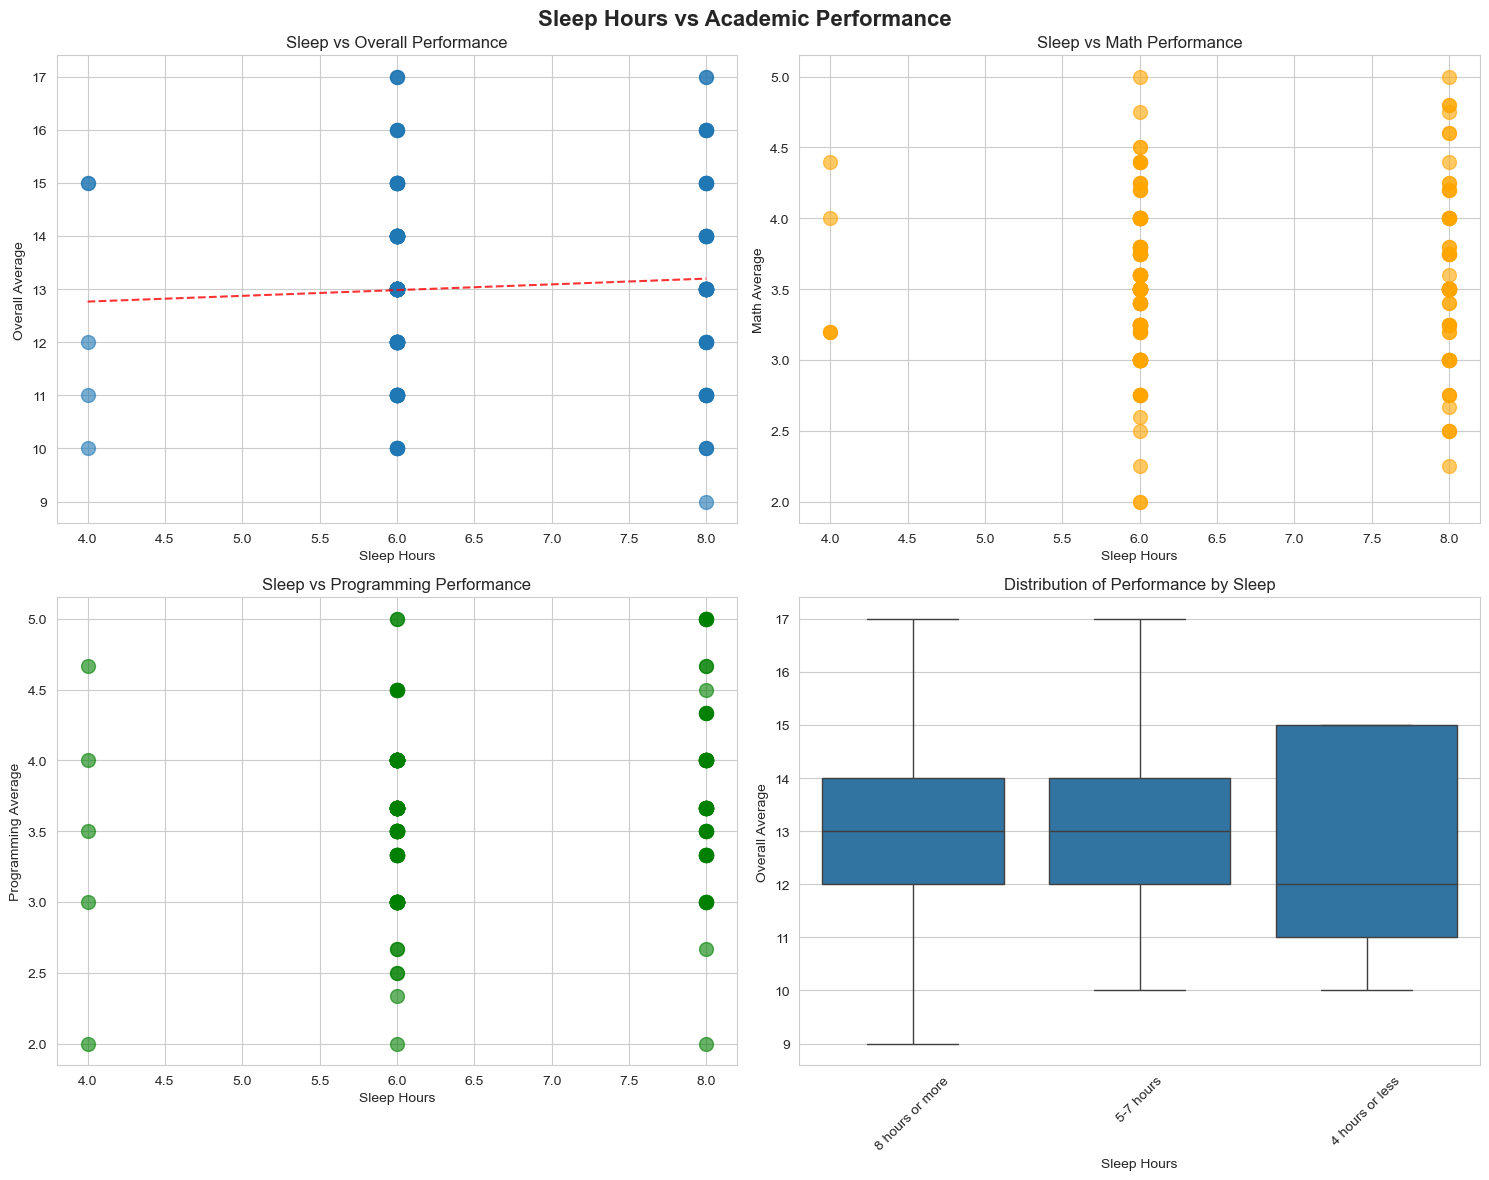


Correlation between sleep and overall performance: 0.067


In [20]:
print("\n\n" + "=" * 80)
print("ANALYSIS 1: SLEEP HOURS VS PERFORMANCE")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Sleep Hours vs Academic Performance', fontsize=16, fontweight='bold')

# Overall average
axes[0, 0].scatter(data_1y['sleep_numeric'], data_1y['1y average'], alpha=0.6, s=100)
axes[0, 0].set_xlabel('Sleep Hours')
axes[0, 0].set_ylabel('Overall Average')
axes[0, 0].set_title('Sleep vs Overall Performance')
z = np.polyfit(data_1y['sleep_numeric'].dropna(), data_1y['1y average'].dropna(), 1)
p = np.poly1d(z)
axes[0, 0].plot(data_1y['sleep_numeric'].dropna().sort_values(), 
                p(data_1y['sleep_numeric'].dropna().sort_values()), "r--", alpha=0.8)

# Math average
axes[0, 1].scatter(data_1y['sleep_numeric'], data_1y['1Y_math_avg'], alpha=0.6, s=100, color='orange')
axes[0, 1].set_xlabel('Sleep Hours')
axes[0, 1].set_ylabel('Math Average')
axes[0, 1].set_title('Sleep vs Math Performance')

# Programming average
axes[1, 0].scatter(data_1y['sleep_numeric'], data_1y['1Y_programming_avg'], alpha=0.6, s=100, color='green')
axes[1, 0].set_xlabel('Sleep Hours')
axes[1, 0].set_ylabel('Programming Average')
axes[1, 0].set_title('Sleep vs Programming Performance')

# Box plot summary
sns.boxplot(data=data_1y, x='how many hours do you sleep', y='1y average', ax=axes[1, 1])
axes[1, 1].set_xlabel('Sleep Hours')
axes[1, 1].set_ylabel('Overall Average')
axes[1, 1].set_title('Distribution of Performance by Sleep')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Correlation statistics
corr = data_1y[['sleep_numeric', '1y average']].corr().iloc[0, 1]
print(f"\nCorrelation between sleep and overall performance: {corr:.3f}")
